# 05 — Experimento 2: Lexicón Loughran-McDonald + Regresión Logística

Segundo experimento: representamos cada minuta por su **tono financiero** en lugar de su
vocabulario. Usamos el diccionario Loughran-McDonald (LM), estándar para análisis de textos
financieros, para extraer **6 scores de tono** por documento, y entrenamos la misma regresión
logística que en el Exp 1.

A diferencia de TF-IDF (10 000 features léxicas que el modelo memorizó), aquí hay solo 6
features de dominio. La hipótesis: el tono agregado generaliza mejor a través del drift temporal
porque no depende del vocabulario exacto.

**Input:** `data/processed/fomc_dataset.csv` + `data/raw/lexicons/Loughran-McDonald_MasterDictionary_1993-2025.csv`

**Outputs:** figuras en `reports/figures/` (`05_confusion_val.png`, `05_confusion_test.png`, `05_lm_coef.png`)

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

sns.set_theme(style='whitegrid', palette='Set2')
pd.options.display.max_colwidth = 200

BASE_DIR       = Path('..').resolve()
DATA_RAW       = BASE_DIR / 'data' / 'raw'
LEXICONS_DIR   = DATA_RAW / 'lexicons'
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
REPORTS_DIR    = BASE_DIR / 'reports' / 'figures'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

LABEL_ORDER = ['hike', 'cut', 'hold']

def save_fig(name):
    plt.savefig(REPORTS_DIR / name, dpi=120, bbox_inches='tight')

df = pd.read_csv(DATA_PROCESSED / 'fomc_dataset.csv', parse_dates=['date'])
train = df[df.split == 'train']
val   = df[df.split == 'val']
test  = df[df.split == 'test']
print('train:', len(train), '| val:', len(val), '| test:', len(test))

train: 145 | val: 32 | test: 32


## Nota sobre el dataset y la evaluación

Mismo dataset que el Exp 1: corpus **2000–2025** (209 docs) con etiquetas corregidas
(decisión = tasa antes vs después de cada reunión). Split cronológico **train 2000–2017 (145),
val 2018–2021 (32), test 2022–2025 (32)**, con las **tres clases en los tres conjuntos**. La
comparación de modelos se hace sobre **validación**; el test (2022–2025) es generalización
out-of-sample sobre un período difícil (subas inflacionarias 2022–23 + recortes de normalización
2024–25). val y test son chicos (32 docs) → métricas algo ruidosas.

In [2]:
# Helper de evaluación (idéntico al del notebook 04).
# El F1-macro se promedia solo sobre las clases presentes en y_true y se reporta cuántas son.
def evaluar(y_true, y_pred, titulo, fname=None):
    clases_presentes = [c for c in LABEL_ORDER if c in set(y_true)]
    f1 = f1_score(y_true, y_pred, labels=clases_presentes, average='macro')

    print(titulo)
    print('accuracy :', round(accuracy_score(y_true, y_pred), 4))
    print(f'f1_macro : {round(f1, 4)}  (promedio sobre {len(clases_presentes)} clases presentes: {clases_presentes})')
    print(classification_report(y_true, y_pred, labels=LABEL_ORDER, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, ax=ax)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); ax.set_title(titulo)
    if fname:
        save_fig(fname)
    plt.show()
    return f1

## 1. Cargar el lexicón Loughran-McDonald y construir los conjuntos de tono

El diccionario LM marca cada palabra con el año en que entró en cada categoría (0 = no
pertenece). Construimos un conjunto de palabras por categoría. Usamos las **6 categorías del
plan**: Positive, Negative, Uncertainty, Litigious, Strong Modal, Weak Modal.

In [3]:
# Cargar lexicón local (sin descargas)
LM_PATH = LEXICONS_DIR / 'Loughran-McDonald_MasterDictionary_1993-2025.csv'
if not LM_PATH.exists():
    LM_PATH = LEXICONS_DIR / 'LM_MasterDictionary.csv'  # fallback
lm_df = pd.read_csv(LM_PATH)
print('Lexicón:', LM_PATH.name, '|', len(lm_df), 'palabras')

# Las 6 categorías del spec; nombres de columna exactos del Master Dictionary
LM_CATEGORIES = ['Positive', 'Negative', 'Uncertainty', 'Litigious', 'Strong_Modal', 'Weak_Modal']

# En el Master Dictionary, el valor de cada columna es el AÑO en que la palabra entró a la
# categoría. Un valor NEGATIVO (p. ej. -2020) indica que fue ELIMINADA de la categoría ese año.
# Por eso filtramos con `> 0` (palabras actualmente en la categoría), no con `!= 0`, que
# re-incluiría palabras removidas (p. ej. 'effective', 'great' en Positive; 'force', 'closed'
# en Negative). dropna() descarta la única fila con Word vacío.
lm_sets = {cat: set(lm_df.loc[lm_df[cat] > 0, 'Word'].dropna().str.lower()) for cat in LM_CATEGORIES}
print('\nTamaño de cada conjunto LM (palabras vigentes):')
for cat, words in lm_sets.items():
    print(f'  {cat:13s}: {len(words):>5} palabras')

Lexicón: Loughran-McDonald_MasterDictionary_1993-2025.csv | 86553 palabras

Tamaño de cada conjunto LM (palabras vigentes):
  Positive     :   347 palabras
  Negative     :  2345 palabras
  Uncertainty  :   297 palabras
  Litigious    :   903 palabras
  Strong_Modal :    19 palabras
  Weak_Modal   :    27 palabras


In [4]:
# Score de una categoría = fracción de tokens del documento que pertenecen al conjunto
def lm_score(text, word_set):
    tokens = str(text).split()
    if not tokens:
        return 0.0
    return sum(1 for t in tokens if t in word_set) / len(tokens)

# Construir las 6 features por documento
lm_cols = [f'lm_{c.lower()}' for c in LM_CATEGORIES]
for cat, col in zip(LM_CATEGORIES, lm_cols):
    df[col] = df['text'].apply(lambda t, s=lm_sets[cat]: lm_score(t, s))

# Re-derivar las particiones ya con las features calculadas
train = df[df.split == 'train']
val   = df[df.split == 'val']
test  = df[df.split == 'test']

X_train, y_train = train[lm_cols].values, train['label']
X_val,   y_val   = val[lm_cols].values,   val['label']
X_test,  y_test  = test[lm_cols].values,  test['label']
print('X_train:', X_train.shape, '(6 features de tono)')

X_train: (145, 6) (6 features de tono)


## 2. Señal de tono por clase

Antes de clasificar, verificamos que los scores discriminen las clases (replica el hallazgo del
EDA: `Negative` más alto en `cut`).

In [5]:
scores_label = df.groupby('label')[lm_cols].mean().loc[LABEL_ORDER]
scores_label.columns = LM_CATEGORIES
print('Score LM promedio por clase:')
display(scores_label.round(4))

ratio = scores_label.loc['cut', 'Negative'] / scores_label.loc['hike', 'Negative']
print(f'\nNegative: cut={scores_label.loc["cut","Negative"]:.4f} vs hike={scores_label.loc["hike","Negative"]:.4f}  (cut {ratio:.2f}x)')

Score LM promedio por clase:


,Positive,Negative,Uncertainty,Litigious,Strong_Modal,Weak_Modal
label,,,,,,
hike,0.0171,0.0250,0.0277,0.0033,0.0007,0.0130
cut,0.0147,0.0407,0.0284,0.0037,0.0009,0.0121
hold,0.0175,0.0300,0.0274,0.0037,0.0008,0.0128



Negative: cut=0.0407 vs hike=0.0250  (cut 1.62x)


## 3. Baseline trivial

Misma cota inferior que en el Exp 1: `DummyClassifier(strategy='prior')`.

Baseline (majority) — VAL
accuracy : 0.75
f1_macro : 0.2857  (promedio sobre 3 clases presentes: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       0.00      0.00      0.00         4
         cut       0.00      0.00      0.00         4
        hold       0.75      1.00      0.86        24

    accuracy                           0.75        32
   macro avg       0.25      0.33      0.29        32
weighted avg       0.56      0.75      0.64        32



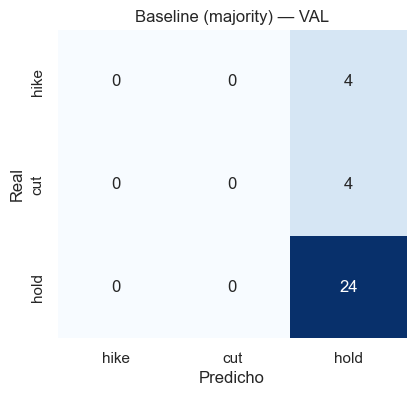

Baseline (majority) — TEST
accuracy : 0.4688
f1_macro : 0.2128  (promedio sobre 3 clases presentes: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       0.00      0.00      0.00        11
         cut       0.00      0.00      0.00         6
        hold       0.47      1.00      0.64        15

    accuracy                           0.47        32
   macro avg       0.16      0.33      0.21        32
weighted avg       0.22      0.47      0.30        32



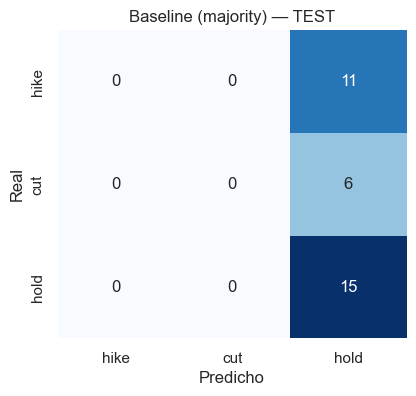

0.2127659574468085

In [6]:
dummy = DummyClassifier(strategy='prior')
dummy.fit(X_train, y_train)
evaluar(y_val,  dummy.predict(X_val),  'Baseline (majority) — VAL')
evaluar(y_test, dummy.predict(X_test), 'Baseline (majority) — TEST')

## 4. Lexicón LM + Regresión Logística

Pipeline: estandarizamos las 6 features (los scores son fracciones pequeñas de escalas
distintas) y entrenamos la regresión logística con `class_weight='balanced'`. El `StandardScaler`
se ajusta **solo sobre train** dentro del Pipeline. Tuneamos `C` sobre validación.

In [7]:
C_grid = [0.01, 0.1, 1, 10]
resultados = []
for C in C_grid:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=C, max_iter=1000, class_weight='balanced')),
    ])
    pipe.fit(X_train, y_train)
    f1_val = f1_score(y_val, pipe.predict(X_val),
                      labels=[c for c in LABEL_ORDER if c in set(y_val)], average='macro')
    resultados.append((C, f1_val))
    print(f'C={C:<5} -> F1-macro val = {f1_val:.4f}')

best_C = max(resultados, key=lambda t: t[1])[0]
print(f'\nMejor C (por F1-macro en val): {best_C}')

C=0.01  -> F1-macro val = 0.4887
C=0.1   -> F1-macro val = 0.4401
C=1     -> F1-macro val = 0.4401
C=10    -> F1-macro val = 0.3225

Mejor C (por F1-macro en val): 0.01


LM lexicon + LogReg (C=0.01) — VAL
accuracy : 0.5
f1_macro : 0.4887  (promedio sobre 3 clases presentes: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       0.19      0.75      0.30         4
         cut       0.67      0.50      0.57         4
        hold       0.85      0.46      0.59        24

    accuracy                           0.50        32
   macro avg       0.57      0.57      0.49        32
weighted avg       0.74      0.50      0.55        32



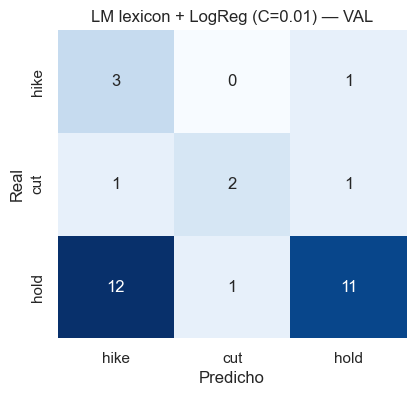

LM lexicon + LogReg (C=0.01) — TEST
accuracy : 0.2812
f1_macro : 0.1538  (promedio sobre 3 clases presentes: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       0.00      0.00      0.00        11
         cut       0.00      0.00      0.00         6
        hold       0.38      0.60      0.46        15

    accuracy                           0.28        32
   macro avg       0.12      0.20      0.15        32
weighted avg       0.18      0.28      0.22        32



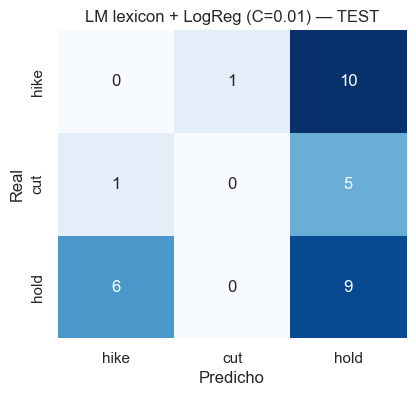

0.15384615384615385

In [8]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=best_C, max_iter=1000, class_weight='balanced')),
])
pipe.fit(X_train, y_train)

evaluar(y_val,  pipe.predict(X_val),  f'LM lexicon + LogReg (C={best_C}) — VAL',  '05_confusion_val.png')
evaluar(y_test, pipe.predict(X_test), f'LM lexicon + LogReg (C={best_C}) — TEST', '05_confusion_test.png')

## 5. Interpretación: peso de cada categoría de tono

Como las features están estandarizadas, los coeficientes son comparables entre sí. Un coeficiente
positivo para (clase, categoría) indica que más de ese tono empuja la predicción hacia esa clase.

Coeficientes (filas = clase, columnas = categoría de tono):


,Positive,Negative,Uncertainty,Litigious,Strong_Modal,Weak_Modal
cut,-0.110,0.392,0.007,0.049,0.077,-0.017
hike,0.104,-0.331,0.033,-0.024,-0.060,0.052
hold,0.007,-0.061,-0.040,-0.025,-0.017,-0.035


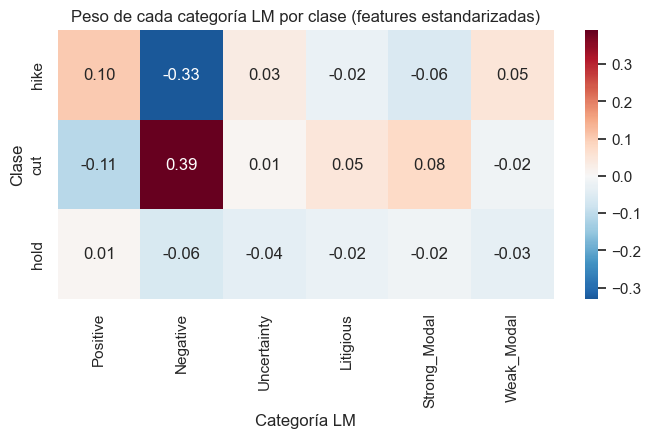

In [9]:
clf = pipe.named_steps['clf']
coef_df = pd.DataFrame(clf.coef_, index=clf.classes_, columns=LM_CATEGORIES)
print('Coeficientes (filas = clase, columnas = categoría de tono):')
display(coef_df.round(3))

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(coef_df.loc[[c for c in LABEL_ORDER if c in clf.classes_]],
            annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Peso de cada categoría LM por clase (features estandarizadas)')
ax.set_xlabel('Categoría LM'); ax.set_ylabel('Clase')
save_fig('05_lm_coef.png')
plt.show()

## 6. Interpretación

**El lexicón LM supera al baseline en validación y detecta las tres clases.** F1-macro en val
**0.489 vs 0.286** (baseline). Con solo **6 features de tono** detecta hike y cut, algo que el
baseline (todo `hold`) no hace. Matriz de confusión val:

```
        hike  cut  hold
hike  [  3    0    1 ]   detecta 3 de 4 hikes
cut   [  1    2    1 ]   detecta 2 de 4 cut
hold  [ 12    1   11 ]   11 de 24 hold (sobre-predice hike: 12 hold → hike)
```

Comparado con TF-IDF (Exp 1, val 0.519): el F1-macro es **apenas menor** (0.489 vs 0.519), pero
el perfil de error es distinto — **LM detecta `cut` y más hikes**, mientras que TF-IDF no detecta
ningún `cut`. A cambio, LM sobre-predice `hike` para muchos `hold` (accuracy más baja, 0.5).

**Los coeficientes confirman la lógica económica** (features estandarizadas):
- `cut` ← **Negative +0.39** (el peso más fuerte del modelo), Positive −0.11. Los recortes
  ocurren en contextos adversos → tono negativo elevado.
- `hike` ← **Positive +0.10, Negative −0.33**. Las subas se asocian a menos tono negativo.
- `hold` ← coeficientes débiles (≈ 0): sin firma de tono propia, clase neutra por defecto.

El modelo aprendió esencialmente un eje **Negative**: mucho tono negativo → `cut`, poco → `hike`.
Coincide con el EDA (Negative en `cut` ≈ 1.62× el de `hike`).

**Pero en test (2022–2025) el modelo falla:** accuracy 0.28, F1-macro **0.154** (por debajo del
baseline 0.213). No detecta ni hikes ni cuts:

```
TEST (real vs predicho)
        hike  cut  hold
hike  [  0    1   10 ]   los 11 hike → casi todos hold
cut   [  1    0    5 ]   los 6 cut → hold (no detecta ninguno)
hold  [  6    0    9 ]   9 de 15 hold
```

**Por qué falla en test, en las dos direcciones:**
- Las **subas de 2022–23** ocurrieron en **inflación alta** → minutas con mucho lenguaje de
  riesgo/preocupación → tono *negativo* elevado. El modelo (que aprendió "negativo → cut") no las
  ve como subas.
- Los **recortes de 2024–25** fueron de **normalización en una economía sana** (desinflación,
  soft landing), **sin** el tono de crisis de los recortes históricos (2008, 2020) que el modelo
  aprendió → no los detecta como cut.

En ambos casos el tono **refleja el estado de la economía, no la decisión de política**.

## Conclusión del experimento

El lexicón LM, con 6 features interpretables, **supera al baseline en validación y detecta las
tres clases** (a diferencia de TF-IDF, que no captura `cut`). Captura una señal económica genuina:
el eje de tono negativo. Pero su límite es de fondo: **el tono mide *cómo está* la economía, no
*qué decide* la Fed**. En test falla en ambas direcciones — confunde las subas anti-inflación
(tono negativo) y se pierde los recortes de normalización (tono no-negativo). Esto motiva los
modelos contextuales/semánticos (Word2Vec, FinBERT), que pueden capturar más que el conteo de
palabras de tono.